In [1]:
import cartopy.crs as ccrs
import cartopy.feature
import matplotlib.pyplot as plt
import calendar
import polars as pl
import numpy as np

from matplotlib.colors import LinearSegmentedColormap

import parcels

/tmp/ipykernel_3729556/3706247970.py:10: UserWarning: This is an alpha version of Parcels v4. The API is not stable and may change without deprecation warnings.
  import parcels


/home/evansebill/Sargassum_growth_model/.pixi/envs/default/lib/python3.14/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/home/evansebill/Sargassum_growth_model/.pixi/envs/default/lib/python3.14/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/home/evansebill/Sargassum_growth_model/.pixi/envs/default/lib/python3.14/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/home/evansebill/Sargassum_growth_model/.pixi/envs/default/lib/python3.14/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  wa

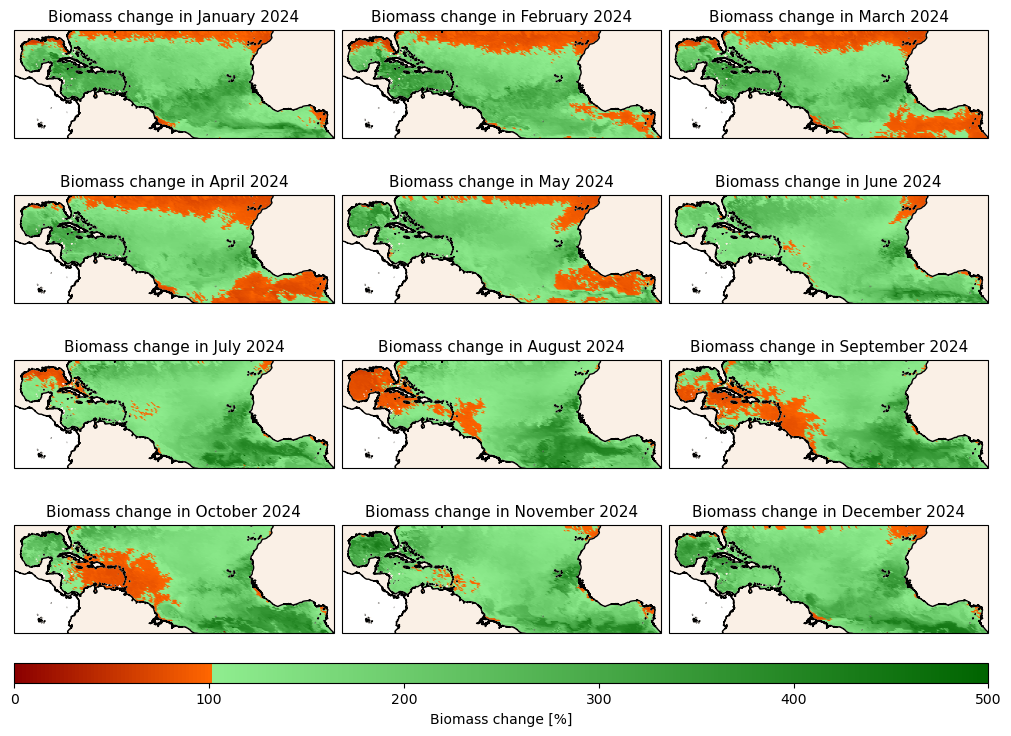

In [2]:
fig, axes = plt.subplots(4, 3, figsize=(10, 7.5), constrained_layout=True, subplot_kw={'projection': ccrs.PlateCarree()})

cmap = LinearSegmentedColormap.from_list(
    'red_orange_green',
    [(0.0, '#8b0000'), (0.2, '#ff6600'), (0.2, '#90ee90'), (1.0, '#006400')]
)

for i, ax in enumerate(axes.flatten()):
    df = parcels.read_particlefile(f"Simulations/Simulation_Basin_2024-{i+1:02d}.parquet")

    to_plot = (
        df.group_by('particle_id')
        .agg([
            pl.col('lon').first().alias('lon'),
            pl.col('lat').first().alias('lat'),
            (pl.col('biomass') * 100).last().alias('biomass')
        ])
        .sort('particle_id')
    )
    cscat = ax.scatter(
        to_plot['lon'], to_plot['lat'], c = to_plot['biomass'],
        cmap=cmap, s=10, linewidth=0, transform=ccrs.PlateCarree(), zorder=2,
        vmin=0, vmax=500,
    )

    ax.add_feature(cartopy.feature.COASTLINE.with_scale('10m'), zorder=3, color='black')
    ax.add_feature(cartopy.feature.LAND.with_scale('10m'), zorder=2, color='linen')
    ax.set_extent([-100, 12, -5, 33], crs=ccrs.PlateCarree())
    ax.set_title(f"Biomass change in {calendar.month_name[i+1]} 2024", fontsize=11)

cbar = fig.colorbar(cscat, ax=axes, orientation='horizontal', pad=0.04, aspect=50, label='Biomass change [%]')

plt.savefig("Figures/Figure8.png", bbox_inches="tight", dpi=300)
plt.show()